# From Machine Learning to Neural Networks


## Why This Chapter Comes First

Before discussing **CNNs** {cite}`lecun1998gradient`, **UNets** {cite}`ronneberger2015u`, **transformers** {cite}`dosovitskiy2021image`, or **generative models**, it is important to fix the conceptual transition from classical inverse problems to learning-based reconstruction. If this transition is not made carefully, neural networks risk appearing as a completely separate subject, disconnected from the operator-theoretic and variational language of computational imaging. In reality, the connection is very direct.

In Module 1, the basic object of study was the forward model

$$
\boldsymbol{y}^\delta = K \boldsymbol{x}^* + \boldsymbol{e},
$$

where $\boldsymbol{x}^* \in \mathbb{R}^n$ denotes the unknown image, $K \in \mathbb{R}^{m \times n}$ is the acquisition operator, and $\boldsymbol{e} \in \mathbb{R}^m$ models the perturbation due to noise, usually $\boldsymbol{e} \sim \mathcal{N}(0, \sigma^2 I)$ for some **noise level** $\sigma > 0$. 

In the modern literature, this problem can be approached by two, complementary approaches: **variational methods** (sometimes named *model-based*), and **data-driven methods**. 


The first approach represents the category of methods that you already studied in the first Module of this course, and comprises all the methods that address reconstruction problem of recovering $\boldsymbol{x}^*$ from $\boldsymbol{y}^\delta$ by exploiting knowledge of $K$, of the noise model, and of suitable regularity assumptions on the unknown image {cite}`kaipio2005statistical`, basically solving the optimization problem:

$$
\boldsymbol{x}^* \in \arg\min_{\boldsymbol{x}} \| K \boldsymbol{x} - \boldsymbol{y}^\delta \|_2^2 + \lambda \mathcal{R}(\boldsymbol{x}),
$$

where the regularization term $\mathcal{R}(\boldsymbol{x})$ controls the prior information on the solution, while $\| K \boldsymbol{x} - \boldsymbol{y}^\delta \|_2^2$ requires the solution to fit the observations $\boldsymbol{y}^\delta$.

On the other side, the learning-based viewpoint works by collecting a training set of examples, comprising couples $(\boldsymbol{y}^\delta, \boldsymbol{x}^*)$ of associate images, and learn a parameterized inverse map

$$
f_\Theta(\boldsymbol{y}^\delta) \mapsto \boldsymbol{x}^*,
$$

directly from that data.

In the intersection between these two approaches there are the **hybrid methods**, which combines techniques from model-based and data-driven algorithms to build powerful and highly-general reconstruction methods. Since these category represents the modern state-of-the-art for image reconstruction, we will discuss them at the end of this Module (particularly, the class of the so-called **generative models**). 

```{image} /imgs/hybrid.png
:width: 450px
:align: center
```

## Basics of Machine Learning

Before diving into the mathematical machinery of deep learning, it is useful to set up the notation and intuitions that will be used throughout the course.

A learning problem is defined by a dataset of $N$ input-output pairs:

$$
\mathcal{D} = \{ (\boldsymbol{x}^{(i)}, \boldsymbol{y}^{(i)}) \}_{i=1}^N,
$$

where $\boldsymbol{x}^{(i)} \in \mathbb{R}^d$ is the input and $\boldsymbol{y}^{(i)} \in \mathbb{R}^s$ is the target output. The goal is to learn a parameterized function $f_{\boldsymbol{\Theta}} : \mathbb{R}^d \to \mathbb{R}^s$ that correctly maps inputs to outputs beyond the training set.

**A concrete example.** Machine learning is widely used to predict house prices based on property characteristics. Suppose each house is described by the following features:

- $x_1$: square footage;
- $x_2$: number of bedrooms;
- $x_3$: number of bathrooms;
- $x_4$: distance to the city centre;
- $x_5$: age of the house.

The goal is to predict the selling price $y$ from these features, so $\boldsymbol{x}^{(i)} \in \mathbb{R}^5$ and $y^{(i)} \in \mathbb{R}$. Initially, the model has no knowledge of how these features influence price. By **training** on historical sales data it discovers patterns and estimates parameters that best fit the observations. Once trained, it can predict the price of new houses not seen during training.

```{warning}
This setup assumes that all data is represented as real numbers. Handling non-numeric data such as categorical features is beyond the scope of this course; those interested should look into *embedding* techniques.
```

**Mathematical formulation.** At its core, an ML model is a function $f_{\boldsymbol{\Theta}} : \mathbb{R}^d \to \mathbb{R}^s$ whose behaviour is entirely determined by its parameter vector $\boldsymbol{\Theta}$. The choice of $s$ depends on the task: in a regression problem $s$ is the number of predicted values; in image reconstruction $s$ is the number of pixels. To build intuition, start with the simplest case $d = s = 1$:

$$
f_{\boldsymbol{\Theta}}(x) = \Theta_1 + \Theta_2\,x.
$$

This is a straight line in the $(x, y)$ plane. The code below plots two different choices of $\boldsymbol{\Theta}$ and shows how dramatically the prediction can change.

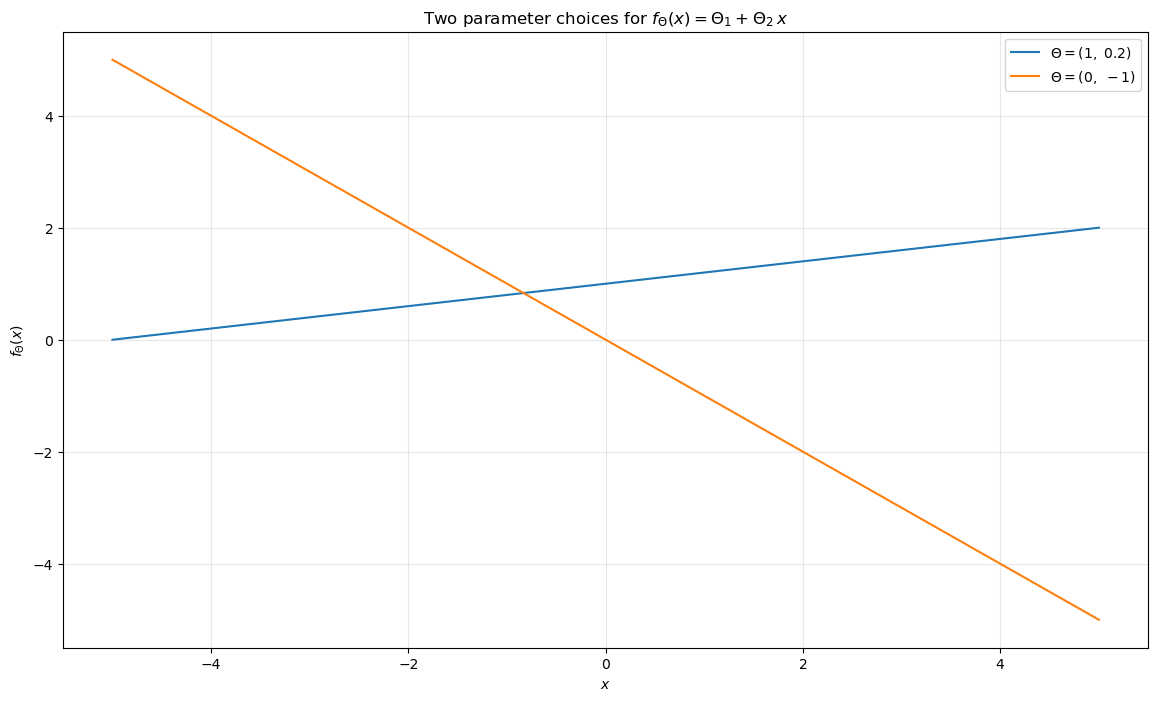

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(theta, x):
    return theta[0] + theta[1] * x

theta1 = (1, 0.2)
theta2 = (0, -1)

xx = np.linspace(-5, 5, 100)

plt.figure(figsize=(14, 8))
plt.plot(xx, f(theta1, xx), label=r'$\Theta = (1,\ 0.2)$')
plt.plot(xx, f(theta2, xx), label=r'$\Theta = (0,\ -1)$')
plt.grid(alpha=0.3)
plt.xlabel('$x$')
plt.ylabel(r'$f_\Theta(x)$')
plt.title(r'Two parameter choices for $f_\Theta(x) = \Theta_1 + \Theta_2\,x$')
plt.legend()
plt.show()

Think of $x$ as the input and $f_{\boldsymbol{\Theta}}(x)$ as the model's prediction. Notice how different choices of $\boldsymbol{\Theta}$ lead to very different outputs. Now overlay the training data on the same plot.

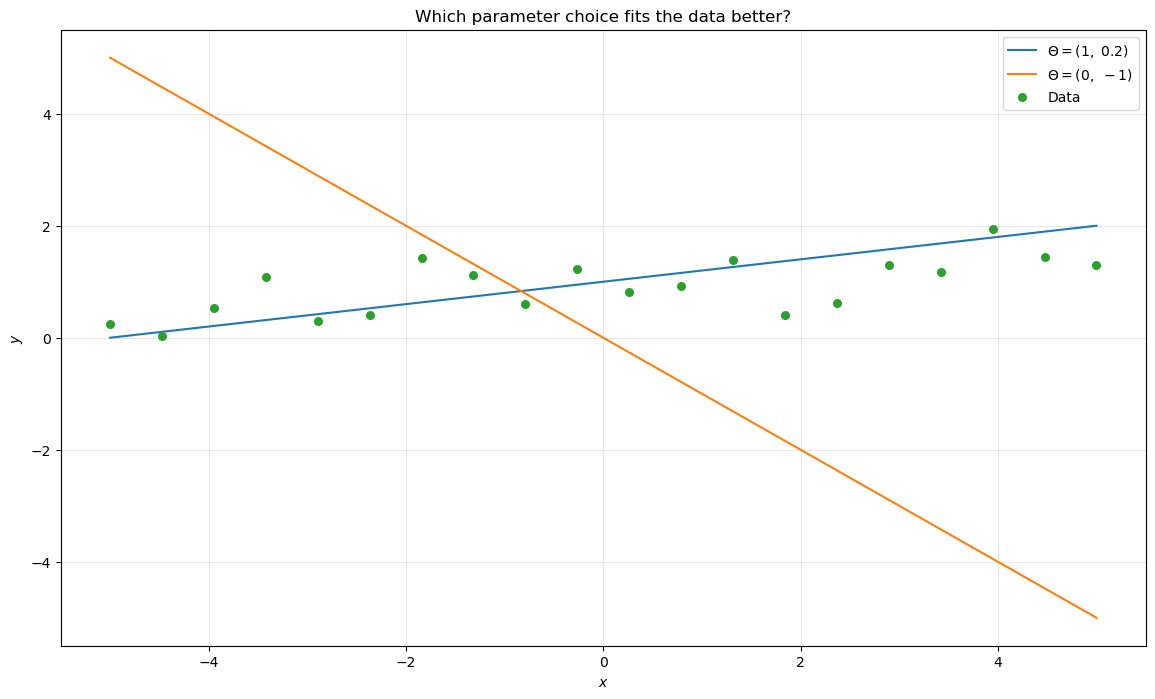

In [2]:
np.random.seed(42)
x_data = np.linspace(-5, 5, 20)
y_data = f(theta1, x_data) + np.random.normal(0, 0.5, x_data.shape)

plt.figure(figsize=(14, 8))
plt.plot(xx, f(theta1, xx), label=r'$\Theta = (1,\ 0.2)$')
plt.plot(xx, f(theta2, xx), label=r'$\Theta = (0,\ -1)$')
plt.scatter(x_data, y_data, s=30, zorder=3, color='C2', label='Data')
plt.grid(alpha=0.3)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('Which parameter choice fits the data better?')
plt.legend()
plt.show()

*Which line fits the data better?* The first one, parameterised by $\boldsymbol{\Theta} = (1, 0.2)$ and, as inspection of the data-generation code confirms, those are exactly the parameters used.

This illustrates two fundamental properties common to almost all ML models:

- Different choices of $\boldsymbol{\Theta}$ lead to *very different* predictions.
- Given a training set, some parameter choices are better than others, and the process of finding the best choice is called **training**.

**Linearity and its limits.** Generalising to arbitrary dimensions, when the input $\boldsymbol{x}$ lies in a $d$-dimensional space and the output $y$ lies in an $s$-dimensional space, the resulting **linear** model writes as:

$$
f_{\boldsymbol{\Theta}}(\boldsymbol{x}) = W\boldsymbol{x} + \boldsymbol{b},
\qquad W \in \mathbb{R}^{s \times d},\; \boldsymbol{b} \in \mathbb{R}^s.
$$

This model, parameterized by $\Theta = (W, \boldsymbol{b})$, comprises a total of $s(d+1)$ parameters, i.e. $sd$ parameters for $W$ and $s$ parameters for $\boldsymbol{b}$. Linear models are easy to analyse and optimize, but their expressivity is fundamentally limited: they can only represent linear functions of the input. Other classical ML methods, such as polynomial regression, Support Vector Machines (SVM), Random Forests, or XGBoost, improve expressivity, but none of them are expressive enough for the complexity of image reconstruction tasks. The simplest way to see the limitation is to try to approximate $\sin(x)$ with an affine model. The code below shows the failure directly.

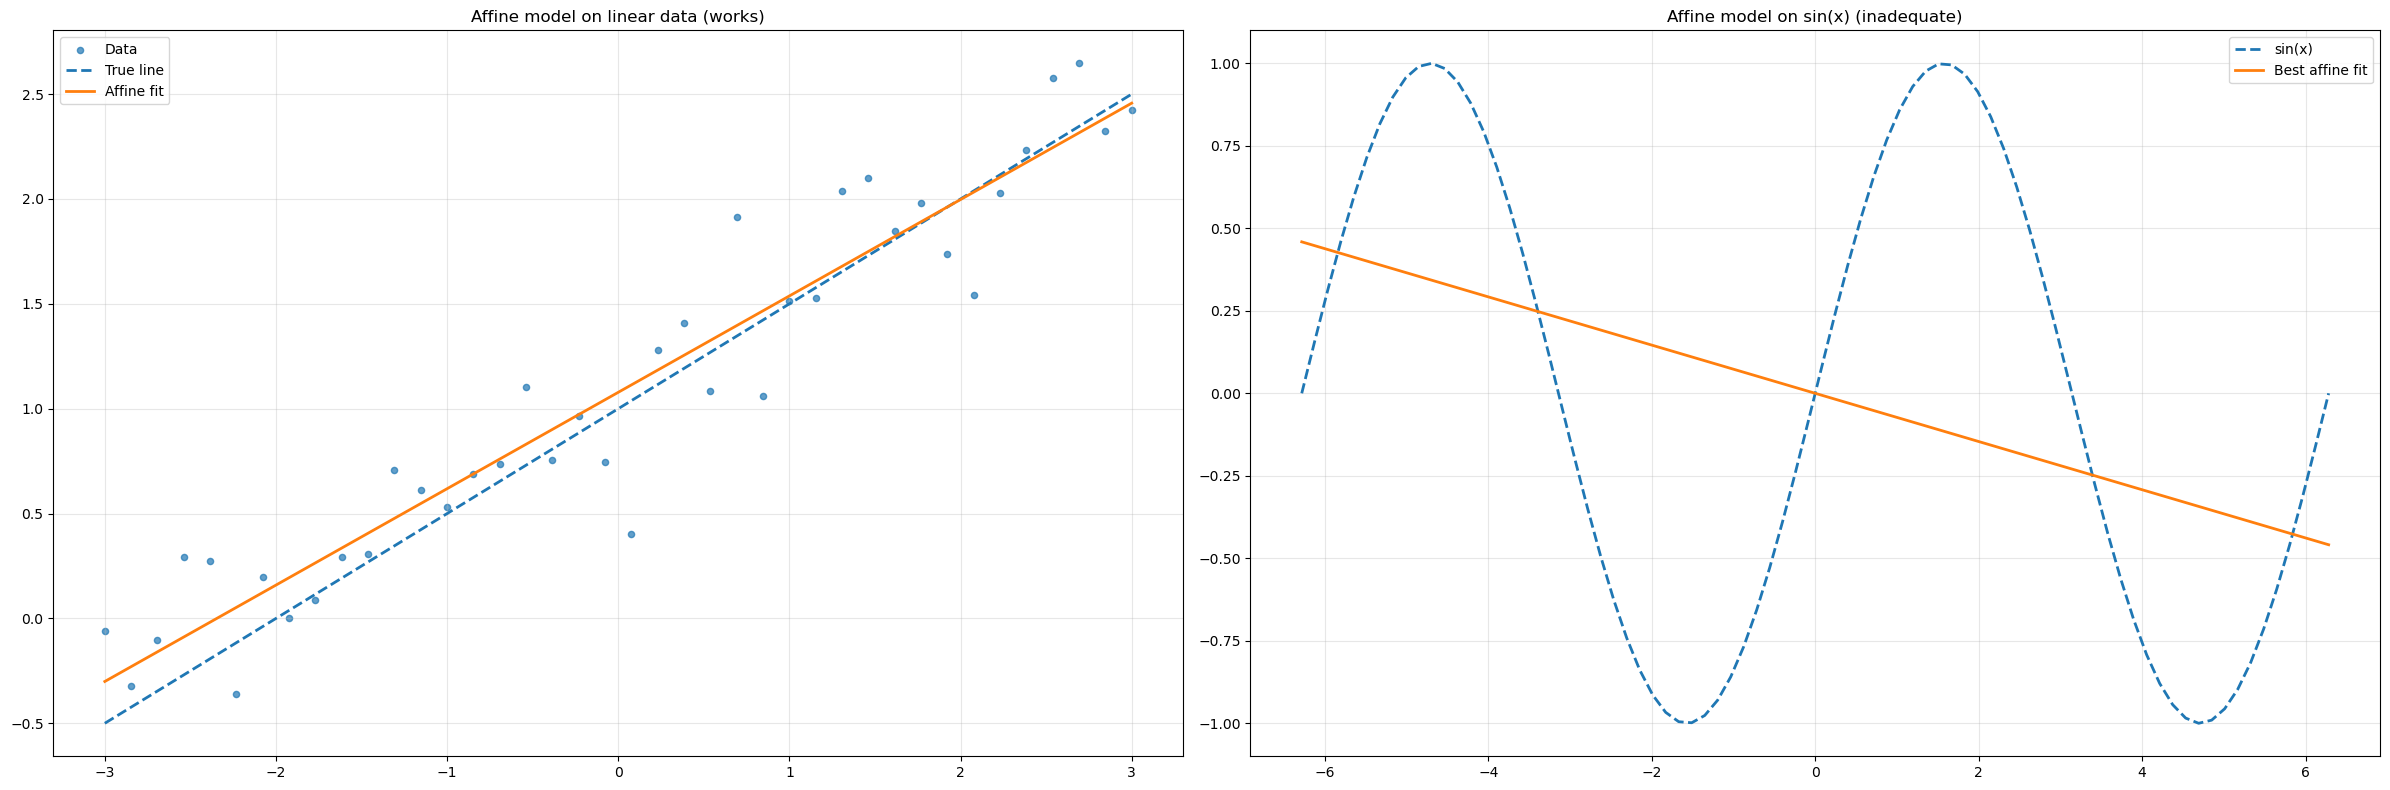

Best-fit affine MSE on sin(x): 0.4218


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.linspace(-2 * np.pi, 2 * np.pi, 80)
y_true = np.sin(x)

# Best-fit affine model via least squares
X = np.column_stack([x, np.ones_like(x)])
theta = np.linalg.lstsq(X, y_true, rcond=None)[0]
y_linear = X @ theta

fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Left: affine model fits linear data well
x_l = np.linspace(-3, 3, 40)
y_l = 0.5 * x_l + 1.0 + 0.25 * np.random.randn(40)
w = np.linalg.lstsq(np.column_stack([x_l, np.ones(40)]), y_l, rcond=None)[0]
axes[0].scatter(x_l, y_l, s=20, alpha=0.7, label='Data')
axes[0].plot(x_l, 0.5 * x_l + 1.0, '--', linewidth=2, label='True line')
axes[0].plot(x_l, w[0] * x_l + w[1], linewidth=2, label='Affine fit')
axes[0].set_title('Affine model on linear data (works)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: affine model cannot fit sin(x)
axes[1].plot(x, y_true, '--', linewidth=2, label='sin(x)')
axes[1].plot(x, y_linear, linewidth=2, label='Best affine fit')
axes[1].set_title('Affine model on sin(x) (inadequate)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Best-fit affine MSE on sin(x): {np.mean((y_linear - y_true)**2):.4f}')

## From Linear Predictors to Neural Networks

A neural network is a specific type of Machine Learning model that has gained significant relevance in recent years due to several factors, including:

- The exponential increase in computational power, particularly with GPUs, which enable extreme *parallelization*.
- The vast amount of data available, largely thanks to the internet.

In this section, we will provide a high-level overview of neural networks. We will then dive deeper into neural networks specifically designed for image processing.  

For a more in-depth understanding of neural networks, we recommend referring to the course by Professor Andrea Asperti which will be held at the beginning of the second year of this Master Degree.  

**Why depth alone does not help.**

The basic idea behind neural networks is fairly simple: linear models are efficient but not expressive enough, so why not stack multiple linear models on top of each other to improve expressivity?

Let

$$
f_1(\boldsymbol{x})=W_1\boldsymbol{x}+\boldsymbol{b}_1,
\qquad
f_2(\boldsymbol{z})=W_2\boldsymbol{z}+\boldsymbol{b}_2.
$$

Then

$$
f_2(f_1(\boldsymbol{x}))
=
W_2(W_1\boldsymbol{x}+\boldsymbol{b}_1)+\boldsymbol{b}_2
=
W_2W_1\boldsymbol{x}+W_2\boldsymbol{b}_1+\boldsymbol{b}_2,
$$

which is again affine. Thus, stacking linear maps without additional nonlinear operations does not enlarge the model class in any essential way.

This is one of the cleanest moments in the course to explain why neural networks require **nonlinear activation** functions. Depth matters, but only once linearity has been broken.


**The role of nonlinear activations.**

We therefore proved that, to build a model that is more expressive than a linear model, we can't just stack multiple linear models. We also need something to break the linearity. In neural networks, the solution is quite simple: we insert non-linear functions between the linear models to introduce non-linearity.

Consider, for example, a simple function like:  

$$
\rho(x) = \max(0, x),
$$  

The plot of this function looks as follows:

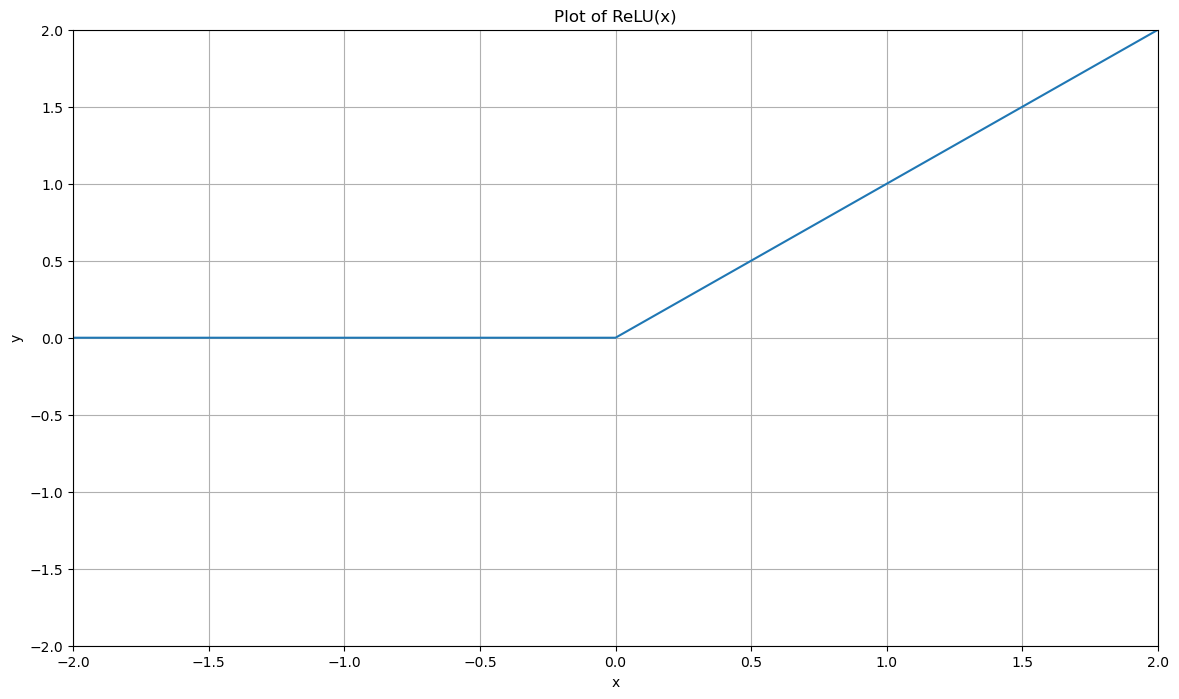

In [4]:
# Define ReLU
def ReLU(x):
    return np.maximum(0, x)

# Define x
x = np.linspace(-5, 5, 21)
y = ReLU(x)

# Plot
plt.figure(figsize=(14, 8))
plt.plot(x, y, '-')
plt.grid()
plt.title("Plot of ReLU(x)")
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

Re-define the model $f_\Theta$ as above, but inserting $\rho(x)$ between the two linear models $f_{\Theta^1}$ and $f_{\Theta^2}$:

$$
f_{\Theta}(x) := f_{\Theta^2} ( \rho (f_{\Theta^1} (x))) = W^2(\rho(W^1x + b^1)) + b^2.
$$

Surprisingly, while this simple modification doesn't seem to drastically change the structure of the stacked linear model discussed earlier, it introduces an incredible property: $f_\Theta(x)$ can approximate *arbitrarily well* any continuous function, thus exhibiting the **Universal Approximation** property. This model, originally called the Multi-layer Perceptron (MLP) due to its layered structure, is the simplest version of a *neural network*.

As we will see in the following, more advanced versions of neural networks can be obtained by:
- Stacking more linear models (always placing a non-linear function in between them),
- Changing the non-linear function used,
- Limiting the structure of the parameter matrices $W^l$ to allow for more efficient computation (this is particularly important for image reconstruction).

More recently, researchers in AI identified other effective non-linear activation functions, generalizing the idea of the ReLU function we just described. In particular, let $\rho:\mathbb{R}\to\mathbb{R}$ be a scalar nonlinear function applied componentwise to vectors. A one-hidden-layer network with activation function $\rho$ takes the form

$$
f_{\boldsymbol{\Theta}}(\boldsymbol{x})=W_2\rho(W_1\boldsymbol{x}+\boldsymbol{b}_1)+\boldsymbol{b}_2.
$$

The choice of activation is a modelling decision with real consequences. The most commonly encountered activations in imaging architectures are listed here (we include ReLU as well for completeness):

**ReLU**, $\rho(t)=\max\{t,0\}$, is the default choice for convolutional networks. It is computationally cheap, avoids the vanishing-gradient problem that plagued earlier sigmoid-based architectures, and produces sparse activations. Its main weakness is that neurons receiving persistently negative input stop contributing entirely (*dead neurons*), which can slow or stall training.

**Leaky ReLU**, $\rho(t)=\max\{\alpha t,\,t\}$ with small $\alpha>0$, is a simple remedy: a small non-zero slope on the negative half-line ensures gradients can always flow back, preventing the dead-neuron problem while preserving most of the computational advantages of ReLU.

**Sigmoid**, $\sigma(t)=\frac{e^t}{1+e^t}$, and **Tanh**, $\tanh(t)=\frac{e^t-e^{-t}}{e^t+e^{-t}}$, are among the oldest activations. Both saturate for large $|t|$, causing vanishing gradients in deep networks, which is why they have largely been replaced by ReLU in hidden layers. They remain relevant as output nonlinearities and in gated recurrent architectures such as LSTMs.

**GELU** is a smooth, differentiable activation motivated by stochastic regularisation. It is the standard choice in transformer-based architectures, where its smoothness interacts better with the self-attention mechanism than the hard thresholding of ReLU.

**SiLU** (Sigmoid Linear Unit), $\rho(t)=t\cdot\sigma(t)$, is a smooth, self-gated activation closely related to GELU and used in EfficientNet and several other modern convolutional architectures.

**Softmax**, $\mathrm{softmax}(\boldsymbol{z})_i = e^{z_i}/\sum_j e^{z_j}$, maps a real-valued vector to a probability distribution. It is not used as a hidden-layer activation but appears as a final-layer nonlinearity in classification tasks and, in image segmentation, converts the output feature map into per-pixel class probabilities.

The role of the activation is deeper than simply introducing nonlinearity. It shapes the geometry of the function class. A ReLU network represents a piecewise affine map whose number of affine regions grows exponentially with depth, a concrete hint of why deep networks can approximate highly complex measurement-to-image relationships.

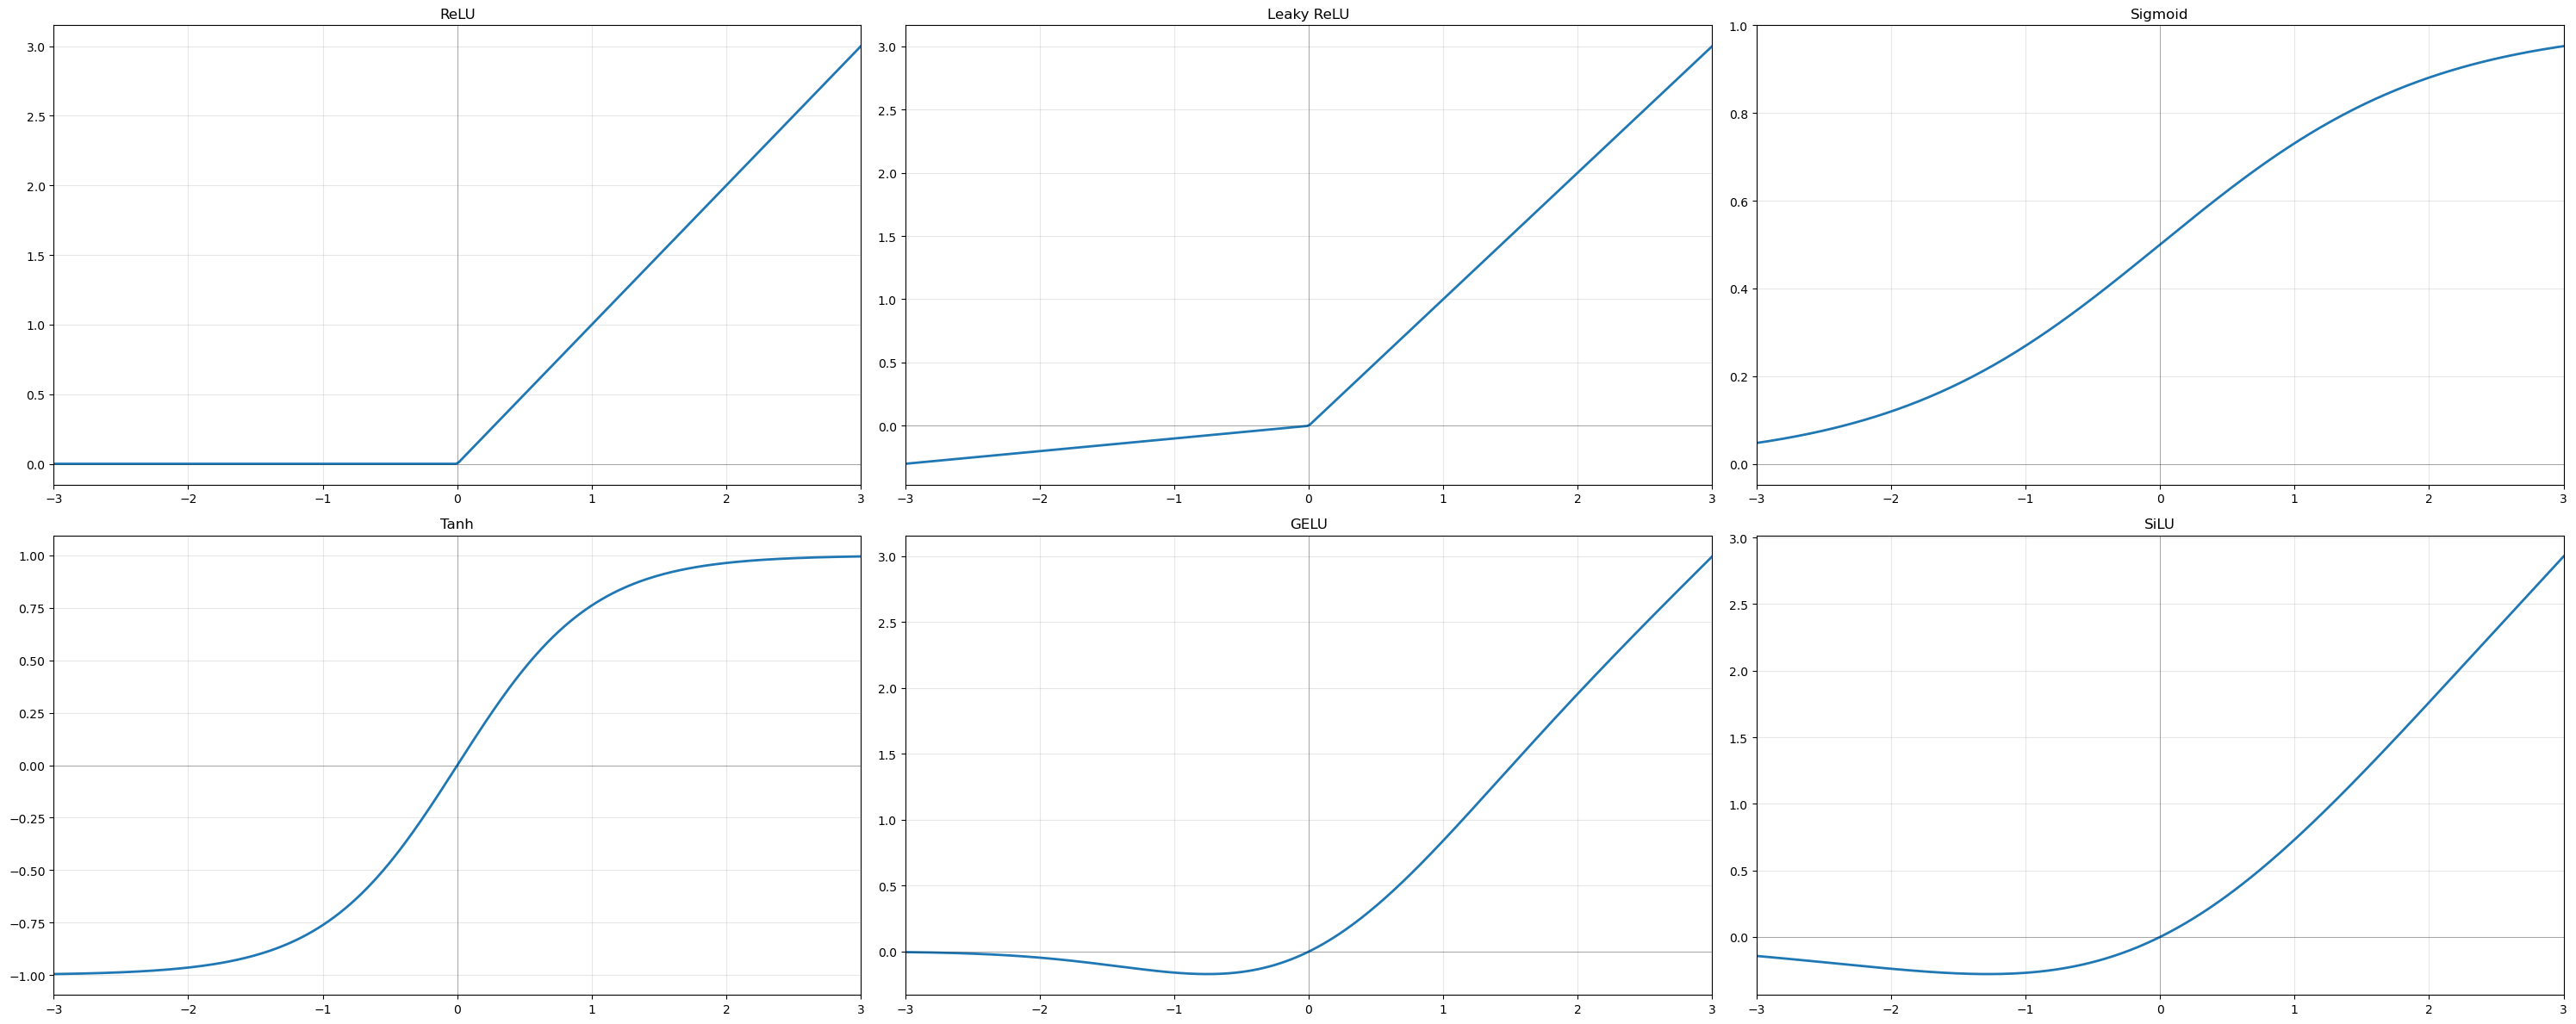

In [5]:
import numpy as np
import matplotlib.pyplot as plt

xx = np.linspace(-3, 3, 300)

relu    = lambda x: np.maximum(0, x)
lrelu   = lambda x: np.where(x > 0, x, 0.1 * x)
sigmoid = lambda x: 1 / (1 + np.exp(-x))
tanh_fn = lambda x: np.tanh(x)
gelu    = lambda x: 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))
silu    = lambda x: x * sigmoid(x)

activations = [
    ('ReLU',       relu(xx)),
    ('Leaky ReLU', lrelu(xx)),
    ('Sigmoid',    sigmoid(xx)),
    ('Tanh',       tanh_fn(xx)),
    ('GELU',       gelu(xx)),
    ('SiLU',       silu(xx)),
]

fig, axes = plt.subplots(2, 3, figsize=(30, 12))
for ax, (name, y) in zip(axes.flat, activations):
    ax.plot(xx, y, linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='k', linewidth=0.5, alpha=0.4)
    ax.set_title(name)
    ax.set_xlim(-3, 3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Notation

```{image} /imgs/NN.png
:width: 500px
:align: center
```

The diagram above makes the architecture concrete. Any neural network can be represented as a layered graph in which each node is called a **neuron**. The layers are:

- **Input layer** ($d$ neurons): holds the input $\boldsymbol{x}$ directly.
- **Hidden layer(s)** ($H$ neurons each, with $H$ the **hidden dimension**): intermediate representations not directly observable from outside. The $i$-th neuron in a hidden layer computes
  $$z_i = \boldsymbol{w}_i^T \boldsymbol{x} + b_i,$$
  where $\boldsymbol{w}_i$ and $b_i$ are the neuron-specific **weights** and **bias**, represented as the edges connecting the previous layer to $z_i$. The activation function then maps $z_i \mapsto h_i = \rho(z_i)$.
- **Output layer** ($s$ neurons): produces the final prediction $\boldsymbol{y}$.

The name *hidden layer* reflects the fact that its values are internal to the computation. Neurons in the input layer are sometimes called the *visible* units.

```{warning}
A common misunderstanding is to think that depth alone creates expressivity. Without **nonlinear activation** functions, composing affine maps still produces an affine map. This is why the activation is a structural ingredient, not an optional embellishment.
```


**Deep Neural Networks.**

The one-hidden-layer architecture above can be extended by stacking $L$ hidden layers, each taking the output of the previous layer as input and applying the same linear-transformation-plus-activation structure. A network with many hidden layers is a **deep neural network**, and the body of algorithms built on such architectures is called **Deep Learning**. The depth $L$ and the width $\max_\ell H_\ell$ (the largest number of neurons across all hidden layers) are the two primary descriptors of a network's capacity.

**Depth, features, and internal representations.**

For a deep network we write

$$
\boldsymbol{h}_0=\boldsymbol{x},
\qquad
\boldsymbol{h}_{\ell+1}=\rho_\ell(W_\ell \boldsymbol{h}_\ell+\boldsymbol{b}_\ell),
\qquad
f_{\boldsymbol{\Theta}}(\boldsymbol{x})=\boldsymbol{h}_L.
$$

The vectors $\boldsymbol{h}_\ell$ are the internal features produced by the network. In early layers, one typically finds detectors of simple local events: oriented edges, contrast boundaries, and repeated low-level textures. In an imaging context these are exactly the elementary structures that acquisition artifacts and noise distort most noticeably. In the middle layers, elementary features are combined into larger-scale structures (in a medical image this might mean organ boundaries or characteristic geometric patterns of the imaging geometry). In the deepest layers, representations become task-specific: they encode the difference between a true anatomical structure and a reconstruction artifact, or between a genuine edge and ringing introduced by truncation of the measurement.

The network is therefore not only computing a final answer. It is building a progressive and increasingly abstract description of the datum, layer by layer. This hierarchical viewpoint explains why depth matters beyond pure approximation power: a shallow model may approximate the same function in principle, but it cannot organize the computation into a reusable hierarchy of descriptors, which leads to much worse parameter efficiency and generalization.

```{image} /imgs/MLP.png
:width: 620px
:align: center
```

**Universal approximation is not the end of the story.**

The universal approximation theorem is often cited when introducing neural networks. It states, roughly speaking, that sufficiently large networks can approximate continuous functions on compact sets {cite}`cybenko1989approximation`. This result is mathematically important because it proves that nonlinear networks are not fundamentally limited in the way linear models are.

However, this theorem should not be overemphasized in a computational imaging course. In practice, one does not only care about approximation in an abstract sense. One also cares about:

- how many parameters are needed;
- whether the model can be trained stably;
- how the architecture reflects known properties of images;
- whether the reconstructor is robust to noise and operator mismatch.

In other words, the relevant question is not only can a neural network represent the desired inverse map, but rather which neural network architecture represents it efficiently and stably.

This is the precise point at which the course naturally moves from generic neural networks to image-specific architectures.

```{note}
**Neural networks as learned regularizers.**

A very useful bridge with classical inverse problems is the following interpretation. Even if a neural network is trained end-to-end, one can view it as approximating the solution map of a variational problem of the form

$$
\hat{\boldsymbol{x}}(\boldsymbol{y}^\delta)
=
\operatorname*{arg\,min}_{\boldsymbol{x}}
\Big(\mathcal{D}(K\boldsymbol{x},\boldsymbol{y}^\delta)+\mathcal{R}(\boldsymbol{x})\Big),
$$

where $\mathcal{D}$ is a data-fidelity term and $\mathcal{R}$ is a regularizer. This is precisely the MAP estimator under the prior $p(\boldsymbol{x}) \propto e^{-\mathcal{R}(\boldsymbol{x})}$: the regularizer and the log-prior are the same object.

The network does not make $\mathcal{D}$ and $\mathcal{R}$ explicit. What it does, through training on paired data, is to absorb an implicit model of both the forward physics and the image prior into its weights.

This has a direct practical implication. The quality of the implicit regularizer is limited by the quality and diversity of the training distribution. A network trained on a narrow image class carries a strong, restrictive prior. A network trained on diverse data carries a weaker, more flexible one. Knowing this helps explain many failure modes observed when such networks are applied outside their training distribution.
```

## Optimization, Backpropagation, and Generalization

**Training** a neural network means finding the parameters $\Theta$ such that the model's prediction $f_\Theta(\boldsymbol{x}^{(i)})$ best approximates the true target $\boldsymbol{y}^{(i)}$ over the training set. In practice, this requires solving the nonconvex optimization problem

$$
\min_{\boldsymbol{\Theta}} L(\boldsymbol{\Theta}) = \sum_{i=1}^N \ell(f_\Theta(\boldsymbol{x}^{(i)}), y^{(i)}).
$$

This problem is usually solved by the gradient descent, namely by iterating:

$$
\boldsymbol{\Theta}_{k+1}
=
\boldsymbol{\Theta}_k-\eta_k\nabla L(\boldsymbol{\Theta}_k).
$$

However, since in practical application the total number of datapoints $N$ can be very large, computing:

$$
\nabla L(\boldsymbol{\Theta}_k) = \sum_{i=1}^N  \nabla  \ell(f_\Theta(\boldsymbol{x}^{(i)}), y^{(i)})
$$

can be computationally prohibitive. For this reason, in practice one rarely computes the full empirical gradient. Instead one uses **minibatches** and obtains a stochastic approximation:

$$
\boldsymbol{\Theta}_{k+1}
=
\boldsymbol{\Theta}_k-\eta_k \sum_{i\in B_k} \nabla \ell(f_\Theta(\boldsymbol{x}^{(i)}), y^{(i)}),
$$

where $B_k$ denotes the current **batch**. The resulting algorithm, known as **Stochastic Gradient Descent (SGD)**, represent one turning point that allowed neural networks to reach the popularity they have today.

Another, crucial component of neural network training is how $\ell(f_\Theta(\boldsymbol{x}^{(i)}), y^{(i)})$ is computed. In practice, this is usually done via **backpropagation** {cite}`rumelhart1986learning`, which is simply an efficient implementation of the chain rule through the **computational graph**, which exploits the recursive architecture of neural network models defined above. 

In [6]:
import torch

layer = torch.nn.Linear(1, 1)
x = torch.tensor([[2.0]])
target = torch.tensor([[1.0]])

prediction = layer(x)
loss = torch.mean((prediction - target) ** 2)
loss.backward()

print('Prediction:', prediction.item())
print('Loss:', loss.item())
print('Gradient with respect to the weight:', layer.weight.grad.item())
print('Gradient with respect to the bias:', layer.bias.grad.item())


Prediction: 1.625720500946045
Loss: 0.39152613282203674
Gradient with respect to the weight: 2.5028820037841797
Gradient with respect to the bias: 1.2514410018920898


**Statistical **generalization**.**

Another key topic to explain explicitly is **generalization**. A network may minimize the training loss very well and still fail on new data. In the inverse-problems setting this issue is even more delicate because the test datum may differ from training not only in image content, but also in:

- noise level;
- acquisition geometry;
- calibration;
- discretization;
- anatomical class or object class.

Thus, when we say that a network generalizes, we mean that the learned inverse map remains reliable under realistic variation in both the unknown image and the measurement process.

This is why one should teach students very early that reconstruction quality cannot be separated from dataset design. A model trained on unrealistic synthetic pairs may generalize only inside a narrow artificial world.


**Why the next step must be image-specific architectures.**

At this point the motivation for image-oriented architectures is clear. Fully connected networks are conceptually useful but computationally and statistically inefficient for images. They do not respect locality, do not exploit translational patterns, and ignore the geometry of the image grid.

Once the idea of a learned inverse map is clear, one asks how to design the architecture so that it matches the structure of image data. The principal answers developed in the imaging literature are:

- **Convolutional networks** {cite}`lecun1998gradient`, which exploit locality and translation invariance through shared filter banks, dramatically reducing parameter count while encoding the inductive bias that meaningful patterns are local and can appear anywhere in the image;
- **Residual networks** {cite}`he2016deep`, which enable very deep architectures by adding identity skip connections that preserve gradient flow and allow later layers to refine rather than relearn earlier representations;
- **Encoder-decoder networks** such as the U-Net {cite}`ronneberger2015u`, which process the image at multiple spatial resolutions and use skip connections to preserve fine-scale detail — the architecture that has become the de facto standard for image-to-image learning in medical and scientific imaging;
- **Attention mechanisms and vision transformers** {cite}`dosovitskiy2021image`, which allow long-range dependencies between spatially distant image regions, going beyond what a purely local convolutional approach can capture.

Each of these is not a generic computational trick. It is a structured response to a specific property of images and of the inverse problems defined on them.

## Exercises

1. Show explicitly that the composition of three linear maps is still linear. Proceeding by recursion, prove that the composition of every number of linear model is linear.
2. Explain in your own words why the loss function changes the statistical estimator learned by the network.


## Further Reading

For a comprehensive treatment of the statistical foundations of neural network training, see {cite}`goodfellow2016deep` and {cite}`bishop2006pattern`. The theoretical and probabilistic foundations of inverse problems, including the role of noise, regularization, and prior information, are developed rigorously in {cite}`kaipio2005statistical`. The specific question of how deep learning techniques apply to imaging inverse problems, including the risk minimization perspective, generalization considerations, and connections to classical reconstruction theory, is surveyed in {cite}`ongie2020deep`.

The original backpropagation algorithm is due to {cite}`rumelhart1986learning`; understanding this paper remains one of the best ways to internalize what automatic differentiation actually computes.